Part 1: Setup & Data Loading
In this section, we'll set up our environment and load the cleaned data we prepared in the previous notebook.

In [3]:

# --- Cell 1: Imports & Environment Setup ---
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set a nice style for our plots
sns.set_style('whitegrid')

print("Setup Complete. Libraries imported.")
# --- Cell 2: Load Cleaned Data ---
# Load the output from our previous notebook
cleaned_data_path = '../data/processed/01_cleaned_btc_data.csv'
df = pd.read_csv(cleaned_data_path, index_col='Date', parse_dates=True)

# Display the first few rows to confirm it loaded correctly
print(f"Successfully loaded data from: {cleaned_data_path}")
print(f"Data shape: {df.shape}")
display(df.head())

Setup Complete. Libraries imported.
Successfully loaded data from: ../data/processed/01_cleaned_btc_data.csv
Data shape: (19248, 5)


,Open,High,Low,Close,Volume
Date,,,,,
2024-01-01 00:00:00,42283.58,42554.57,42261.02,42475.23,1271.68108
2024-01-01 01:00:00,42475.23,42775.00,42431.65,42613.56,1196.37856
2024-01-01 02:00:00,42613.57,42638.41,42500.00,42581.10,685.21980
2024-01-01 03:00:00,42581.09,42586.64,42230.08,42330.49,794.80391
2024-01-01 04:00:00,42330.50,42399.99,42209.46,42399.99,715.41760


In [5]:
# --- Cell 3: Calculate Simple Moving Averages (SMA) ---

# Calculate the 20-period Simple Moving Average
df['sma_20'] = df['Close'].rolling(window=20).mean()

# Calculate the 50-period Simple Moving Average
df['sma_50'] = df['Close'].rolling(window=50).mean()

# Display the last few rows to confirm
print("SMA features added successfully!")
display(df.tail())

SMA features added successfully!


,Open,High,Low,Close,Volume,sma_20,sma_50
Date,,,,,,,
2026-03-12 19:00:00,69819.64,70548.81,69770.85,70432.32,757.84664,69940.6995,70001.5338
2026-03-12 20:00:00,70432.33,70555.20,70111.28,70164.49,618.18553,69937.6570,70004.5462
2026-03-12 21:00:00,70164.50,70470.00,70164.50,70268.55,355.90233,69959.0190,70009.0446
2026-03-12 22:00:00,70268.54,70305.26,70013.17,70175.64,467.42484,70003.4730,70007.8454
2026-03-12 23:00:00,70175.64,70531.43,70159.35,70506.05,260.88427,70056.4450,70022.7062


In [6]:
# --- Cell 4: Calculate Relative Strength Index (RSI) ---

def calculate_rsi(data, period=14):
    """Calculates the RSI for a given period."""
    # Calculate the price difference
    delta = data['Close'].diff(1)
    
    # Separate gains and losses
    gain = (delta.where(delta > 0, 0)).rolling(window=period).mean()
    loss = (-delta.where(delta < 0, 0)).rolling(window=period).mean()
    
    # Calculate the Relative Strength (RS)
    rs = gain / loss
    
    # Calculate the RSI
    rsi = 100 - (100 / (1 + rs))
    return rsi

# Calculate the 14-period RSI and add it to the DataFrame
df['rsi_14'] = calculate_rsi(df, period=14)

# Display the last few rows to see our new RSI column
print("RSI feature added successfully!")
display(df.tail())

RSI feature added successfully!


,Open,High,Low,Close,Volume,sma_20,sma_50,rsi_14
Date,,,,,,,,
2026-03-12 19:00:00,69819.64,70548.81,69770.85,70432.32,757.84664,69940.6995,70001.5338,62.688844
2026-03-12 20:00:00,70432.33,70555.20,70111.28,70164.49,618.18553,69937.6570,70004.5462,58.293537
2026-03-12 21:00:00,70164.50,70470.00,70164.50,70268.55,355.90233,69959.0190,70009.0446,55.856436
2026-03-12 22:00:00,70268.54,70305.26,70013.17,70175.64,467.42484,70003.4730,70007.8454,53.417689
2026-03-12 23:00:00,70175.64,70531.43,70159.35,70506.05,260.88427,70056.4450,70022.7062,56.794069


In [7]:
# --- Cell 5: Calculate Moving Average Convergence Divergence (MACD) ---

# Define the standard periods for MACD
fast_period = 12
slow_period = 26
signal_period = 9

# Calculate the Fast and Slow Exponential Moving Averages (EMA)
ema_fast = df['Close'].ewm(span=fast_period, adjust=False).mean()
ema_slow = df['Close'].ewm(span=slow_period, adjust=False).mean()

# Calculate the MACD line
df['macd'] = ema_fast - ema_slow

# Calculate the Signal line (which is an EMA of the MACD line)
df['macd_signal'] = df['macd'].ewm(span=signal_period, adjust=False).mean()

# You can also calculate the MACD Histogram if you want!
df['macd_hist'] = df['macd'] - df['macd_signal']

# Display the last few rows to see the new MACD columns
print("MACD features added successfully!")
display(df.tail())


MACD features added successfully!


,Open,High,Low,Close,Volume,sma_20,sma_50,rsi_14,macd,macd_signal,macd_hist
Date,,,,,,,,,,,
2026-03-12 19:00:00,69819.64,70548.81,69770.85,70432.32,757.84664,69940.6995,70001.5338,62.688844,54.270352,24.681597,29.588755
2026-03-12 20:00:00,70432.33,70555.20,70111.28,70164.49,618.18553,69937.6570,70004.5462,58.293537,53.931145,30.531506,23.399639
2026-03-12 21:00:00,70164.50,70470.00,70164.50,70268.55,355.90233,69959.0190,70009.0446,55.856436,61.351867,36.695578,24.656289
2026-03-12 22:00:00,70268.54,70305.26,70013.17,70175.64,467.42484,70003.4730,70007.8454,53.417689,59.055033,41.167469,17.887563
2026-03-12 23:00:00,70175.64,70531.43,70159.35,70506.05,260.88427,70056.4450,70022.7062,56.794069,82.940020,49.521979,33.418040


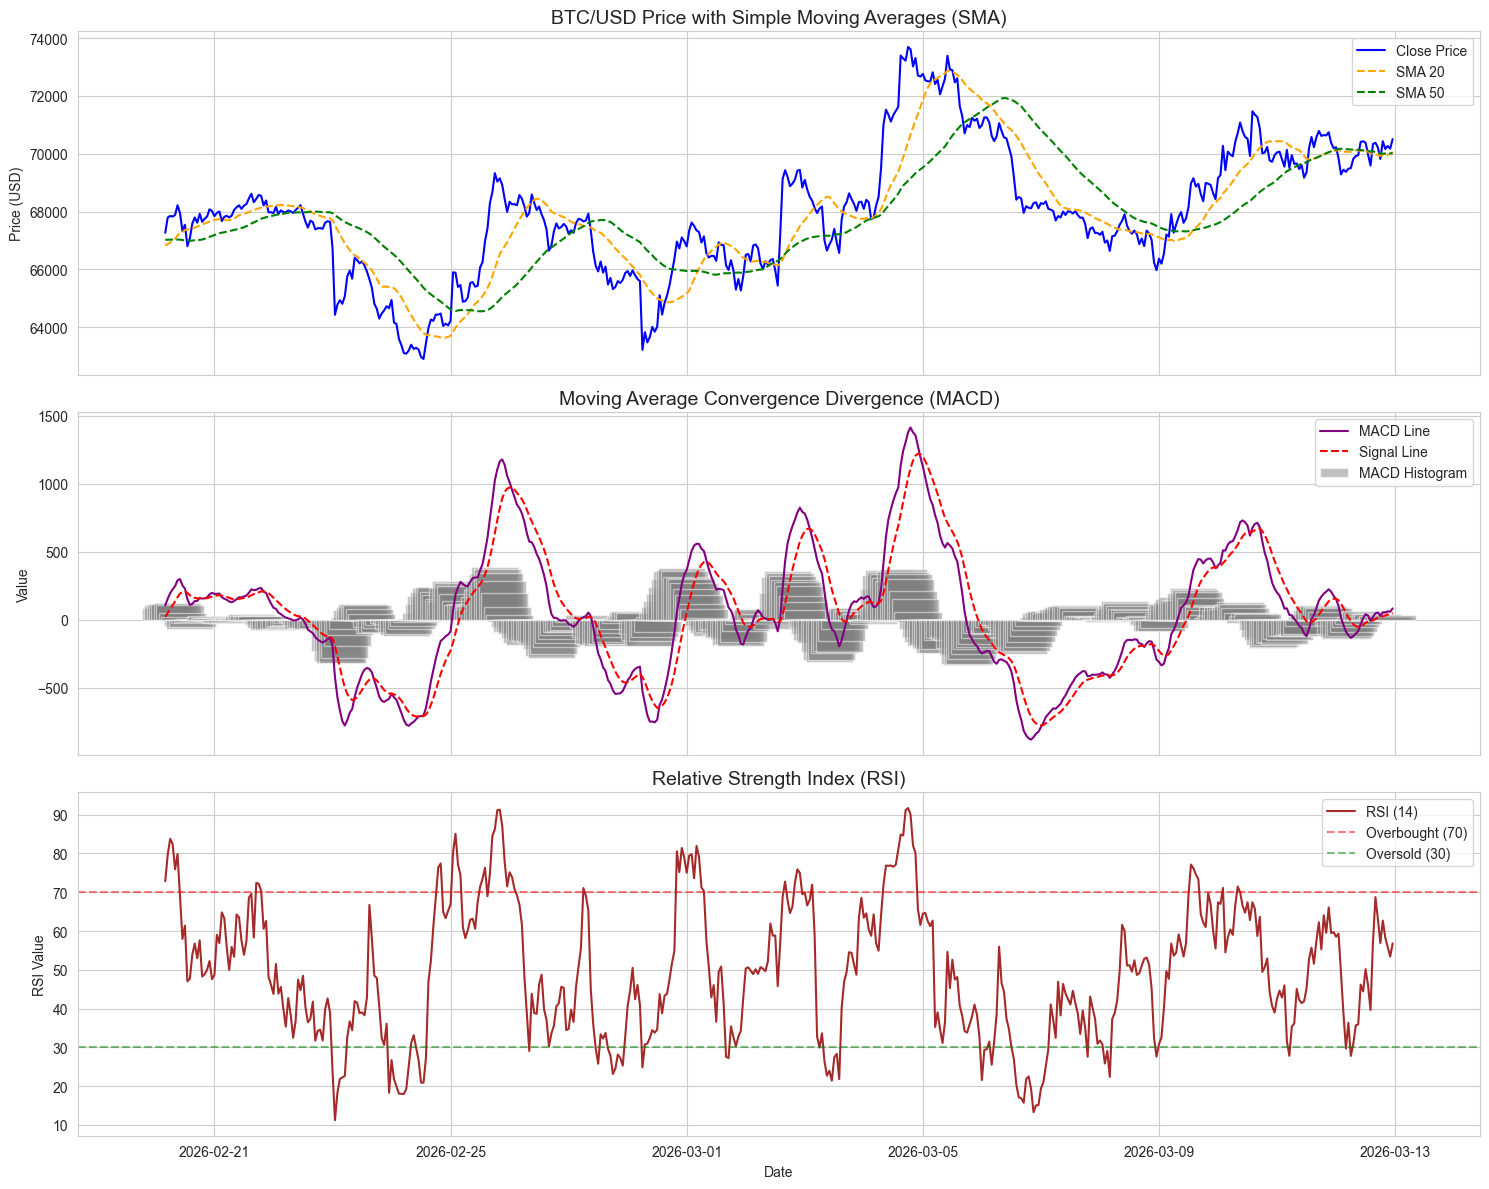

In [8]:
# --- Cell 6: Visualize Price and Engineered Features ---

# Let's plot the last 500 hours to get a clear view
plot_data = df.tail(500)

# Create a figure with 3 subplots, sharing the x-axis
fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(15, 12), sharex=True)

# --- Plot 1: Price and Simple Moving Averages ---
ax1.plot(plot_data.index, plot_data['Close'], label='Close Price', color='blue')
ax1.plot(plot_data.index, plot_data['sma_20'], label='SMA 20', color='orange', linestyle='--')
ax1.plot(plot_data.index, plot_data['sma_50'], label='SMA 50', color='green', linestyle='--')
ax1.set_title('BTC/USD Price with Simple Moving Averages (SMA)', fontsize=14)
ax1.set_ylabel('Price (USD)')
ax1.legend()
ax1.grid(True)

# --- Plot 2: MACD Indicator ---
ax2.plot(plot_data.index, plot_data['macd'], label='MACD Line', color='purple')
ax2.plot(plot_data.index, plot_data['macd_signal'], label='Signal Line', color='red', linestyle='--')
# Use a bar chart for the histogram for better visualization
ax2.bar(plot_data.index, plot_data['macd_hist'], label='MACD Histogram', color='grey', alpha=0.5)
ax2.set_title('Moving Average Convergence Divergence (MACD)', fontsize=14)
ax2.set_ylabel('Value')
ax2.legend()
ax2.grid(True)

# --- Plot 3: RSI Indicator ---
ax3.plot(plot_data.index, plot_data['rsi_14'], label='RSI (14)', color='brown')
# Add overbought and oversold lines
ax3.axhline(70, linestyle='--', color='red', alpha=0.5, label='Overbought (70)')
ax3.axhline(30, linestyle='--', color='green', alpha=0.5, label='Oversold (30)')
ax3.set_title('Relative Strength Index (RSI)', fontsize=14)
ax3.set_xlabel('Date')
ax3.set_ylabel('RSI Value')
ax3.legend()
ax3.grid(True)


# Show the plot
plt.tight_layout()
plt.show()

In [9]:
# --- Cell 7: Calculate Bollinger Bands and Volatility ---

# Define the period for Bollinger Bands (standard is 20)
period = 20
# Define the number of standard deviations (standard is 2)
std_dev = 2

# 1. Calculate the Middle Band (which is just the 20-period SMA)
# We already have this as 'sma_20', but we can calculate it again for clarity if we want.
df['bb_middle'] = df['Close'].rolling(window=period).mean()

# 2. Calculate the rolling standard deviation (this is our volatility measure!)
df['volatility'] = df['Close'].rolling(window=period).std()

# 3. Calculate the Upper and Lower Bands
df['bb_upper'] = df['bb_middle'] + (df['volatility'] * std_dev)
df['bb_lower'] = df['bb_middle'] - (df['volatility'] * std_dev)


# Display the last few rows to see our new features
print("Bollinger Bands and Volatility features added successfully!")
display(df.tail())

Bollinger Bands and Volatility features added successfully!


,Open,High,Low,Close,Volume,sma_20,sma_50,rsi_14,macd,macd_signal,macd_hist,bb_middle,volatility,bb_upper,bb_lower
Date,,,,,,,,,,,,,,,
2026-03-12 19:00:00,69819.64,70548.81,69770.85,70432.32,757.84664,69940.6995,70001.5338,62.688844,54.270352,24.681597,29.588755,69940.6995,394.854169,70730.407838,69150.991162
2026-03-12 20:00:00,70432.33,70555.20,70111.28,70164.49,618.18553,69937.6570,70004.5462,58.293537,53.931145,30.531506,23.399639,69937.6570,392.774431,70723.205862,69152.108138
2026-03-12 21:00:00,70164.50,70470.00,70164.50,70268.55,355.90233,69959.0190,70009.0446,55.856436,61.351867,36.695578,24.656289,69959.0190,398.830135,70756.679269,69161.358731
2026-03-12 22:00:00,70268.54,70305.26,70013.17,70175.64,467.42484,70003.4730,70007.8454,53.417689,59.055033,41.167469,17.887563,70003.4730,368.313685,70740.100369,69266.845631
2026-03-12 23:00:00,70175.64,70531.43,70159.35,70506.05,260.88427,70056.4450,70022.7062,56.794069,82.940020,49.521979,33.418040,70056.4450,360.103130,70776.651260,69336.238740
